<a href="https://colab.research.google.com/github/nicolasDavalos/sis420_IA_Davalos_Alvarez_Nicolas_Darko/blob/main/PRACTICA01_sis420_Davalos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ── Conectar Kaggle y descargar dataset ──────────────────────────────
import os

# 1. Configurar el token
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_3688feea964e94c22b58038c6781f842'

# 2. Instalar kagglehub
os.system('pip install kagglehub -q')

import kagglehub

# 3. Descargar el dataset (kagglehub lo gestiona automáticamente)
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")

print("✅ Dataset listo en:", path)

100%|██████████| 734k/734k [00:00<00:00, 83.2MB/s]

Extracting files...
✅ Dataset listo en: /root/.cache/kagglehub/datasets/iammustafatz/diabetes-prediction-dataset/versions/1


librerias

In [2]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

#pandas
import pandas as pd

cargar

In [3]:
import os
print(os.listdir(path))  # muestra los archivos en la carpeta descargada

['diabetes_prediction_dataset.csv']


In [4]:
# Cargar el dataset de diabetes desde kagglehub
df = pd.read_csv(path + '/diabetes_prediction_dataset.csv')

# Ver el dataset original antes de cualquier cambio
print("Columnas originales:", df.columns.tolist())
print("Forma original:", df.shape)
print(df.head())

Columnas originales: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
Forma original: (100000, 9)
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [5]:
# Ver el dataset original antes de cualquier cambio
print("Columnas originales:", df.columns.tolist())
print("Forma original:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nPrimeras filas:")
print(df.head())
print("\nValores únicos en columnas de texto:")
for col in df.select_dtypes(include='object').columns:
    print(f"  {col}: {df[col].unique()}")

Columnas originales: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
Forma original: (100000, 9)

Tipos de datos:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Primeras filas:
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6        

dividir las columnas de tipo objeto

In [6]:

# Antes del encoding
print("Forma antes del encoding:", df.shape)

# Convertir 'gender' y 'smoking_history' a columnas binarias
# gender       → gender_Female, gender_Male, gender_Other
# smoking_history → smoking_history_No Info, smoking_history_current,
#                   smoking_history_ever, smoking_history_former,
#                   smoking_history_never, smoking_history_not current
df = pd.get_dummies(df, columns=['gender', 'smoking_history'])

# Verificar resultado
print("Forma después del encoding:", df.shape)
print("Columnas nuevas:", df.columns.tolist())
print(df.head())

Forma antes del encoding: (100000, 9)
Forma después del encoding: (100000, 16)
Columnas nuevas: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'gender_Female', 'gender_Male', 'gender_Other', 'smoking_history_No Info', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']
    age  hypertension  heart_disease    bmi  HbA1c_level  blood_glucose_level  \
0  80.0             0              1  25.19          6.6                  140   
1  54.0             0              0  27.32          6.6                   80   
2  28.0             0              0  27.32          5.7                  158   
3  36.0             0              0  23.45          5.0                  155   
4  76.0             1              1  20.14          4.8                  155   

   diabetes  gender_Female  gender_Male  gender_Other  \
0         0           True        False         False 

cargar los datos de x e y

In [7]:
# Separar features y target
y = df['diabetes'].values.astype('float64')        # convertir a float
X = df.drop(columns=['diabetes']).values.astype('float64')  # convertir a float

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Tipo de X:", X.dtype)   # debe decir float64
print("Tipo de y:", y.dtype)   # debe decir float64

X shape: (100000, 15)
y shape: (100000,)
Tipo de X: float64
Tipo de y: float64


crear la funcion para ver una grafica de los feactures (no es necesaria ya que al ser 15 solo graficaremos 2 y pues no nos ayuda a entender realmente como esta los 15 feactures)

In [8]:
def plotData(X, y):
    # Grafica los puntos de datos X y y en una nueva figura.
    # * negro para diabéticos (positivos)
    # o amarillo para no diabéticos (negativos)

    fig = pyplot.figure()

    pos = y == 1
    neg = y == 0

    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=10)
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1)

llamar a la funcion

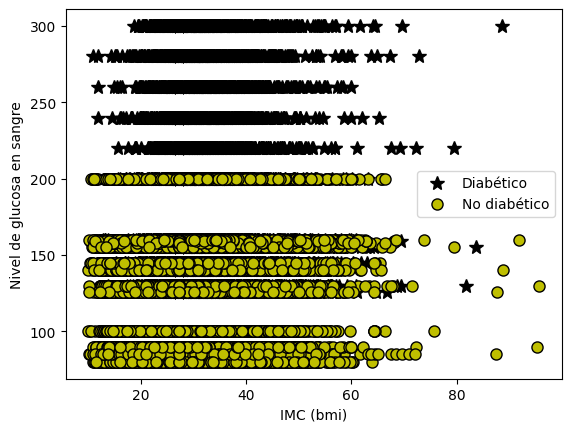

In [9]:
# Para graficar elegimos 2 columnas numéricas representativas:
# columna 4 = bmi, columna 6 = blood_glucose_level
# (posiciones dentro de X después del encoding)
X_plot = df[['bmi', 'blood_glucose_level']].values

plotData(X_plot, y)
pyplot.xlabel('IMC (bmi)')
pyplot.ylabel('Nivel de glucosa en sangre')
pyplot.legend(['Diabético', 'No diabético'])
pass

creamos la funcion sigmoide

In [10]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

prueba

In [11]:
# Prueba la implementacion de la funcion sigmoid
z = [-100, 0.5, 1000000]
g = sigmoid(z)

print('g(', z, ') = ', g)

g( [-100, 0.5, 1000000] ) =  [3.72007598e-44 6.22459331e-01 1.00000000e+00]


normalizacion

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Media de X (debe ser ~0):", X.mean(axis=0).round(2))
print("Std de X (debe ser ~1):", X.std(axis=0).round(2))

Media de X (debe ser ~0): [ 0.  0.  0. -0. -0. -0. -0. -0.  0. -0.  0.  0. -0.  0.  0.]
Std de X (debe ser ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


agregar la columna de 1

In [13]:
# Configurar la matriz y agregar columna de unos (término de intercepción/bias)
m, n = X.shape
print("m (ejemplos):", m)   # esperado: 100000
print("n (features):", n)   # esperado: 15

# Agrega columna de unos al inicio
X = np.concatenate([np.ones((m, 1)), X], axis=1)
print("Nueva forma de X:", X.shape)  # esperado: (100000, 16)

m (ejemplos): 100000
n (features): 15
Nueva forma de X: (100000, 16)


funcion de costo

In [14]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

descenso gradiente

In [15]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

graficacion

Theta calculado por el descenso por el gradiente:
 [-4.07175864  0.70781873  0.18364726  0.14130117  0.45218238  1.63347751
  1.10913223 -0.05267448  0.05308814 -0.01506656 -0.14177585  0.05450307
  0.03366985  0.05809909  0.04943946  0.02053839]

Paciente: 50 años, con hipertensión, BMI=28.5, glucosa=180
Probabilidad de diabetes: 1.00
Predicción (0=No diabético, 1=Diabético): 1


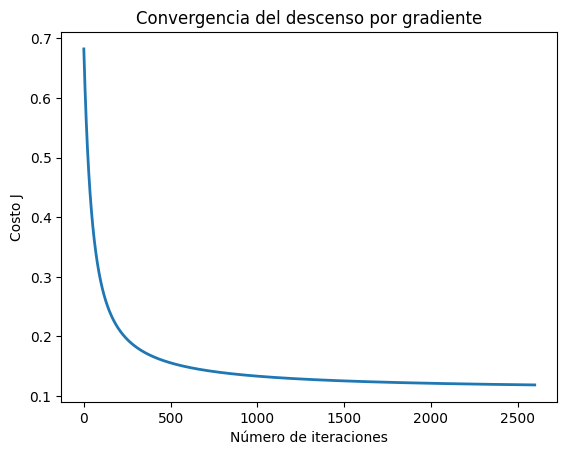

In [20]:
# Elegir valor para alpha y número de iteraciones
alpha = 0.05
num_iters = 2600

# Inicializar theta con ceros — debe tener un valor por cada feature + bias
theta = np.zeros(n + 1)  # n=15 features + 1 bias = 16 valores
theta, J_history = descensoGradiente(theta, X, y, alpha, num_iters)

# Graficar la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del descenso por gradiente')

# Mostrar theta calculado
print('Theta calculado por el descenso por el gradiente:\n', theta)

# Verificar predicción para un paciente de ejemplo
# Orden: [bias, age, hypertension, heart_disease, bmi, HbA1c_level,
#         blood_glucose_level, gender_Female, gender_Male, gender_Other,
#         smoking_No Info, smoking_current, smoking_ever,
#         smoking_former, smoking_never, smoking_not current]
X_paciente = [1, 50, 1, 0, 28.5, 6.5, 180, 1, 0, 0, 0, 0, 0, 0, 1, 0]

prob = sigmoid(np.dot(X_paciente, theta))
prediccion = 1 if prob >= 0.5 else 0

print('\nPaciente: 50 años, con hipertensión, BMI=28.5, glucosa=180')
print('Probabilidad de diabetes: {:.2f}'.format(prob))
print('Predicción (0=No diabético, 1=Diabético):', prediccion)

para scipy optimize

funcion de costo con gradiente

In [21]:
def costFunction(theta, X, y):
    m = y.size

    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    grad = (1 / m) * (h - y).dot(X)

    return J, grad

In [22]:
initial_theta = np.zeros(n + 1)
cost, grad = costFunction(initial_theta, X, y)

print('Costo en theta inicial (zeros): {:.3f}'.format(cost))
print('Gradiente en theta inicial (zeros):')
print(grad)

Costo en theta inicial (zeros): 0.693
Gradiente en theta inicial (zeros):
[ 0.415      -0.07195372 -0.05516928 -0.04789147 -0.05978036 -0.11173683
 -0.11700705  0.01047273 -0.01050445  0.0011405   0.03316985 -0.00546762
 -0.00671553 -0.02730734 -0.00760423 -0.00578224]


optimize.minimize

In [23]:
options = {'maxiter': 1000}

initial_theta = np.zeros(n + 1)

res = optimize.minimize(costFunction,
                        initial_theta,
                        (X, y),
                        jac=True,
                        method='TNC',
                        options=options)

cost = res.fun
theta = res.x

print('Costo encontrado por optimize.minimize: {:.3f}'.format(cost))
print('Theta optimizado:')
print(theta)

/tmp/ipykernel_1523/1663470971.py:5: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(costFunction,


Costo encontrado por optimize.minimize: 0.113
Theta optimizado:
[-5.32425391  1.04018827  0.19506189  0.14296142  0.59033265  2.50570308
  1.35810322 -0.06633341  0.06789271 -0.09831659 -0.20697352  0.08668813
  0.04855675  0.05542506  0.0678045   0.02142567]


graficacion inecesaria

In [24]:
def plotDecisionBoundary(plotData, theta, X, y):
    theta = np.array(theta)

    # Usamos solo las columnas 1 y 2 de X para graficar (bmi y blood_glucose_level)
    plotData(X[:, 1:3], y)

    # Calcular línea de decisión con solo esas 2 features
    plot_x = np.array([np.min(X[:, 1]) - 2, np.max(X[:, 1]) + 2])
    plot_y = (-1. / theta[2]) * (theta[1] * plot_x + theta[0])

    pyplot.plot(plot_x, plot_y)
    pyplot.legend(['Diabético', 'No diabético', 'Límite de decisión'])
    pyplot.xlabel('BMI (normalizado)')
    pyplot.ylabel('Glucosa en sangre (normalizado)')

llamar

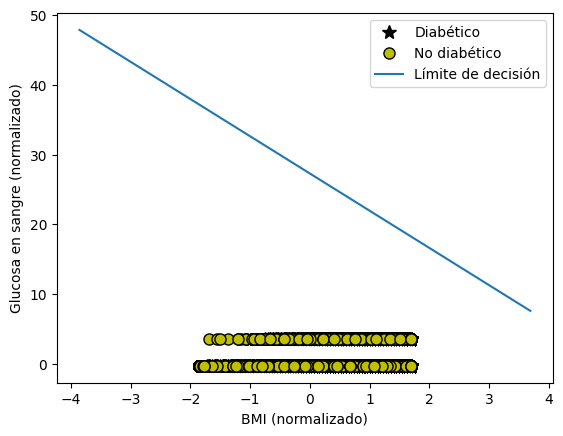

In [26]:
# Graficar límites
plotDecisionBoundary(plotData, theta, X, y)

prueba

In [25]:
def predict(theta, X):
    m = X.shape[0]
    p = np.round(sigmoid(X.dot(theta.T)))
    return p

In [27]:
# Predicción para un paciente de ejemplo (ya normalizado)
X_paciente_raw = np.array([[50, 1, 0, 28.5, 6.5, 180, 1, 0, 0, 0, 0, 0, 0, 1, 0]])
X_paciente_scaled = scaler.transform(X_paciente_raw)
X_paciente_final = np.concatenate([[1], X_paciente_scaled[0]])

prob = sigmoid(np.dot(X_paciente_final, theta))
print('Probabilidad de diabetes para el paciente de ejemplo: {:.3f}'.format(prob))

# Precisión sobre el conjunto de entrenamiento
p = predict(theta, X)
print('Precisión de entrenamiento: {:.2f} %'.format(np.mean(p == y) * 100))

Probabilidad de diabetes para el paciente de ejemplo: 0.392
Precisión de entrenamiento: 96.03 %
